In [1]:
# ===============================
# STA5703 Project Step 1
# King County House Sales (Kaggle)
# ===============================

suppressPackageStartupMessages({
  library(tidyverse)
  library(caret)
  library(MASS)
  library(car)
  library(leaps)
  library(broom)
})

set.seed(5703)

fig_dir <- "figures_step1"
if (!dir.exists(fig_dir)) dir.create(fig_dir)


In [2]:
# Load Data

df_raw <- read.csv("kc_house_data.csv")

cat("Rows:", nrow(df_raw), "\nCols:", ncol(df_raw), "\n\n")
glimpse(df_raw)
summary(df_raw$price)


Rows: 21613 
Cols: 21 

Rows: 21,613
Columns: 21
$ id            <dbl> 7129300520, 6414100192, 5631500400, 2487200875, 19544005…
$ date          <chr> "20141013T000000", "20141209T000000", "20150225T000000",…
$ price         <dbl> 221900, 538000, 180000, 604000, 510000, 1225000, 257500,…
$ bedrooms      <int> 3, 3, 2, 4, 3, 4, 3, 3, 3, 3, 3, 2, 3, 3, 5, 4, 3, 4, 2,…
$ bathrooms     <dbl> 1.00, 2.25, 1.00, 3.00, 2.00, 4.50, 2.25, 1.50, 1.00, 2.…
$ sqft_living   <int> 1180, 2570, 770, 1960, 1680, 5420, 1715, 1060, 1780, 189…
$ sqft_lot      <int> 5650, 7242, 10000, 5000, 8080, 101930, 6819, 9711, 7470,…
$ floors        <dbl> 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1…
$ waterfront    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ view          <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0,…
$ condition     <int> 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3, 3, 4, 4,…
$ grade         <int> 7, 7, 6, 7, 8, 11, 7, 7, 7, 7, 8, 7, 7, 7, 7, 9, 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  75000  321950  450000  540088  645000 7700000 

In [3]:
# Clean Types + Drop ID/Date From Modeling

df <- df_raw

# Parse date if present (often formatted like "20141013T000000")
if ("date" %in% names(df)) {
  df <- df %>% mutate(date = as.Date(substr(date, 1, 8), format = "%Y%m%d"))
}

# Convert likely categorical predictors (if present)
df <- df %>%
  mutate(
    zipcode = if ("zipcode" %in% names(.)) as.factor(zipcode) else NULL,
    waterfront = if ("waterfront" %in% names(.)) as.factor(waterfront) else NULL,
    view = if ("view" %in% names(.)) as.factor(view) else NULL,
    condition = if ("condition" %in% names(.)) as.factor(condition) else NULL,
    grade = if ("grade" %in% names(.)) as.factor(grade) else NULL
  )

# Create modeling dataset (remove identifiers)
drop_cols <- intersect(names(df), c("id", "date"))
df_model <- dplyr::select(df, -dplyr::all_of(drop_cols))

stopifnot("price" %in% names(df_model))
glimpse(df_model)


Rows: 21,613
Columns: 19
$ price         <dbl> 221900, 538000, 180000, 604000, 510000, 1225000, 257500,…
$ bedrooms      <int> 3, 3, 2, 4, 3, 4, 3, 3, 3, 3, 3, 2, 3, 3, 5, 4, 3, 4, 2,…
$ bathrooms     <dbl> 1.00, 2.25, 1.00, 3.00, 2.00, 4.50, 2.25, 1.50, 1.00, 2.…
$ sqft_living   <int> 1180, 2570, 770, 1960, 1680, 5420, 1715, 1060, 1780, 189…
$ sqft_lot      <int> 5650, 7242, 10000, 5000, 8080, 101930, 6819, 9711, 7470,…
$ floors        <dbl> 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1…
$ waterfront    <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ view          <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0,…
$ condition     <fct> 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3, 3, 4, 4,…
$ grade         <fct> 7, 7, 6, 7, 8, 11, 7, 7, 7, 7, 8, 7, 7, 7, 7, 9, 7, 7, 7…
$ sqft_above    <int> 1180, 2170, 770, 1050, 1680, 3890, 1715, 1060, 1050, 189…
$ sqft_basement <int> 0, 400, 0, 910, 0, 1530, 0, 0, 730, 0, 1700, 300, 0, 0, …
$ yr_built     

In [4]:
# Missingness Summary + Simple Imputation

missing_summary <- tibble(
  variable = names(df_model),
  n_missing = sapply(df_model, function(x) sum(is.na(x))),
  pct_missing = round(100 * sapply(df_model, function(x) mean(is.na(x))), 3)
) %>% arrange(desc(n_missing))

missing_summary

mode_value <- function(x) {
  ux <- na.omit(x)
  if (length(ux) == 0) return(NA)
  tab <- table(ux)
  names(tab)[which.max(tab)]
}

# Simple imputation for modeling stability:
df_model <- df_model %>%
  mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .))) %>%
  mutate(across(where(is.factor), ~ fct_explicit_na(., na_level = mode_value(.))))

# Confirm missingness resolved
sapply(df_model, function(x) sum(is.na(x)))


variable,n_missing,pct_missing
<chr>,<int>,<dbl>
price,0,0
bedrooms,0,0
bathrooms,0,0
sqft_living,0,0
sqft_lot,0,0
floors,0,0
waterfront,0,0
view,0,0
condition,0,0


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `across(where(is.factor), ~fct_explicit_na(., na_level =
  mode_value(.)))`.
Caused by warning:
! `fct_explicit_na()` was deprecated in forcats 1.0.0.
ℹ Please use `fct_na_value_to_level()` instead.”


price      bedrooms     bathrooms   sqft_living      sqft_lot 
            0             0             0             0             0 
       floors    waterfront          view     condition         grade 
            0             0             0             0             0 
   sqft_above sqft_basement      yr_built  yr_renovated       zipcode 
            0             0             0             0             0 
          lat          long sqft_living15    sqft_lot15 
            0             0             0             0

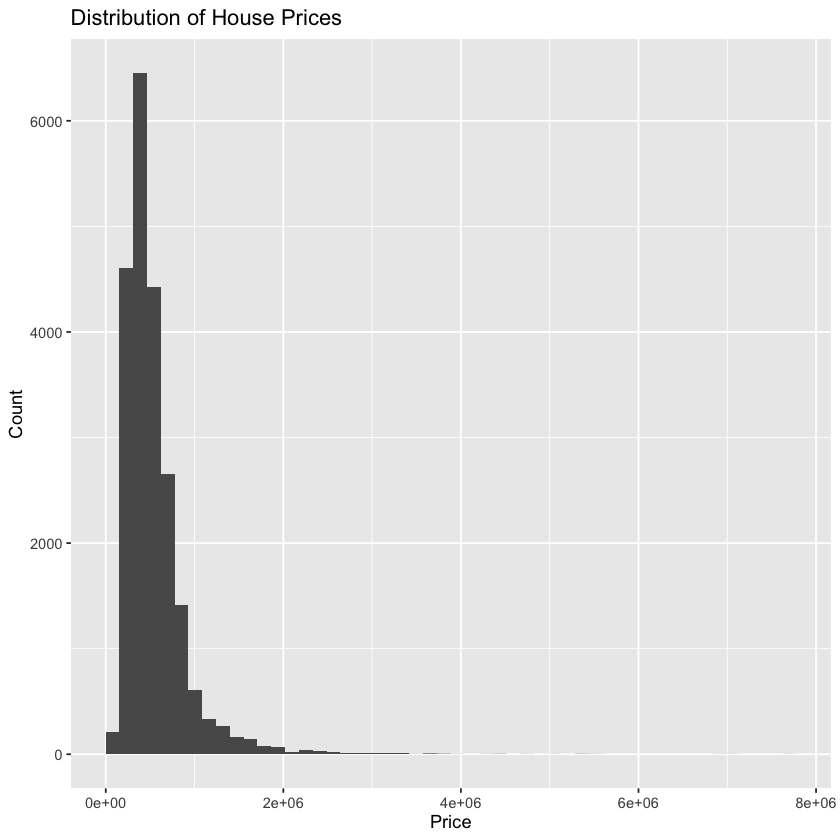

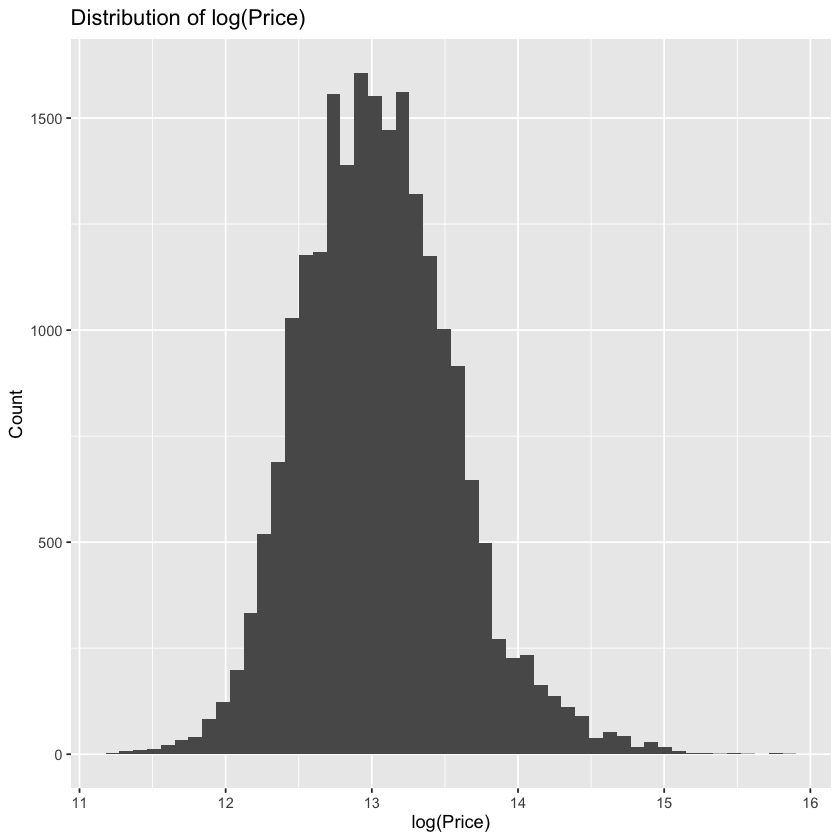

In [5]:
# EDA: Price Histogram + Log(Price) Histogram (Saved)

p_price_hist <- ggplot(df_model, aes(price)) +
  geom_histogram(bins = 50) +
  labs(title = "Distribution of House Prices", x = "Price", y = "Count")

ggsave(file.path(fig_dir, "price_hist.png"), p_price_hist, width = 8, height = 5, dpi = 200)
p_price_hist

p_log_hist <- ggplot(df_model, aes(log(price))) +
  geom_histogram(bins = 50) +
  labs(title = "Distribution of log(Price)", x = "log(Price)", y = "Count")

ggsave(file.path(fig_dir, "logprice_hist.png"), p_log_hist, width = 8, height = 5, dpi = 200)
p_log_hist


price   sqft_living    sqft_above sqft_living15     bathrooms 
   1.00000000    0.70203505    0.60556730    0.58537890    0.52513751 
sqft_basement      bedrooms           lat        floors  yr_renovated 
   0.32381602    0.30834960    0.30700348    0.25679389    0.12643379 
     sqft_lot    sqft_lot15      yr_built          long 
   0.08966086    0.08244715    0.05401153    0.02162624

[1] "sqft_living"   "sqft_above"    "sqft_living15" "bathrooms"

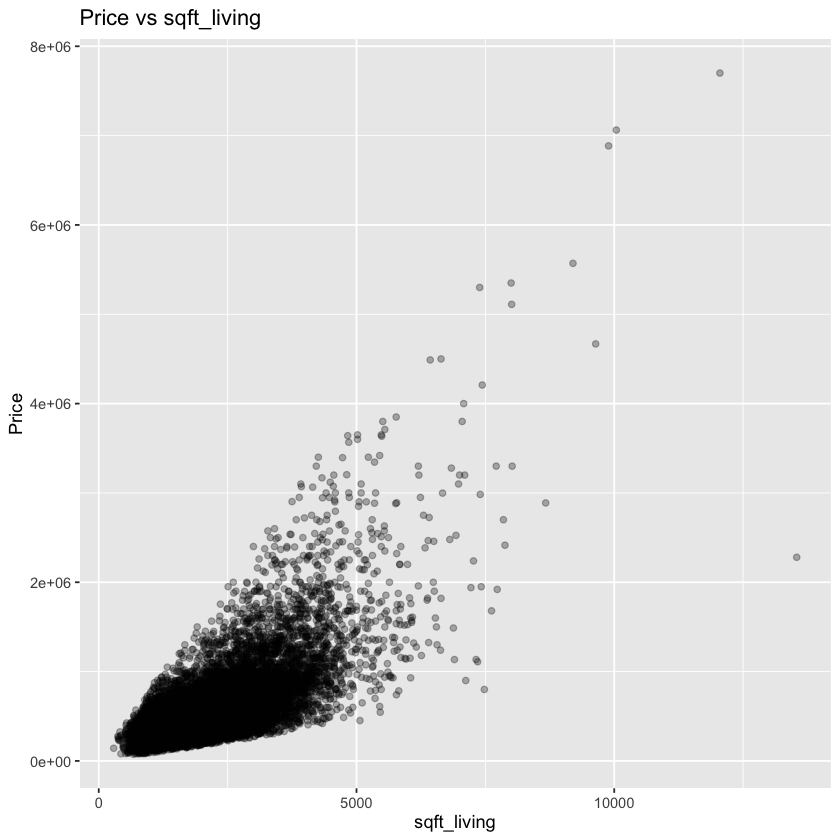

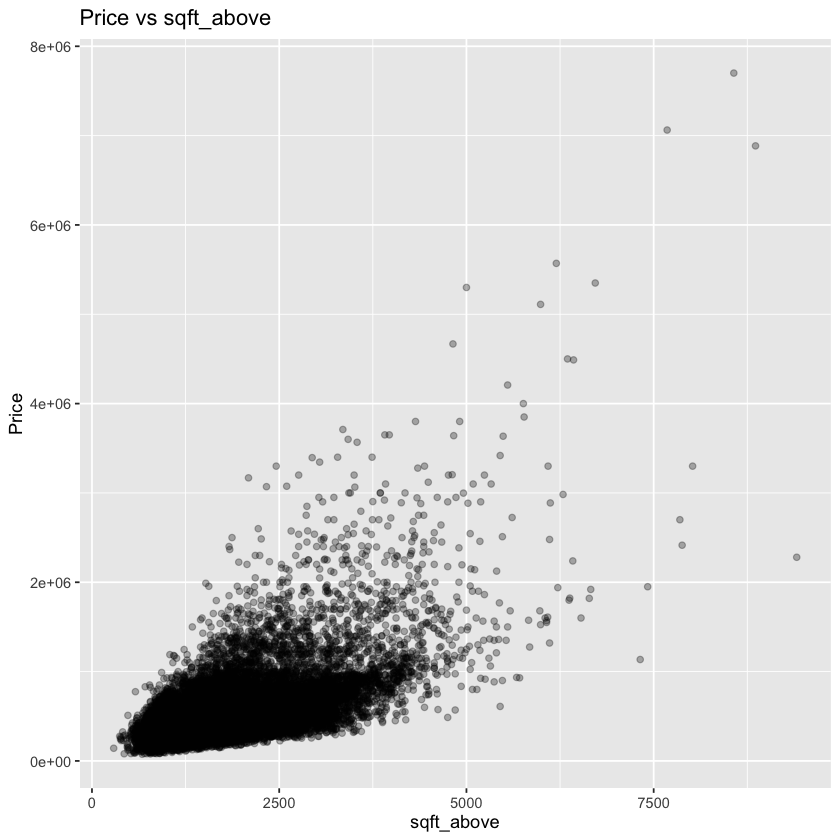

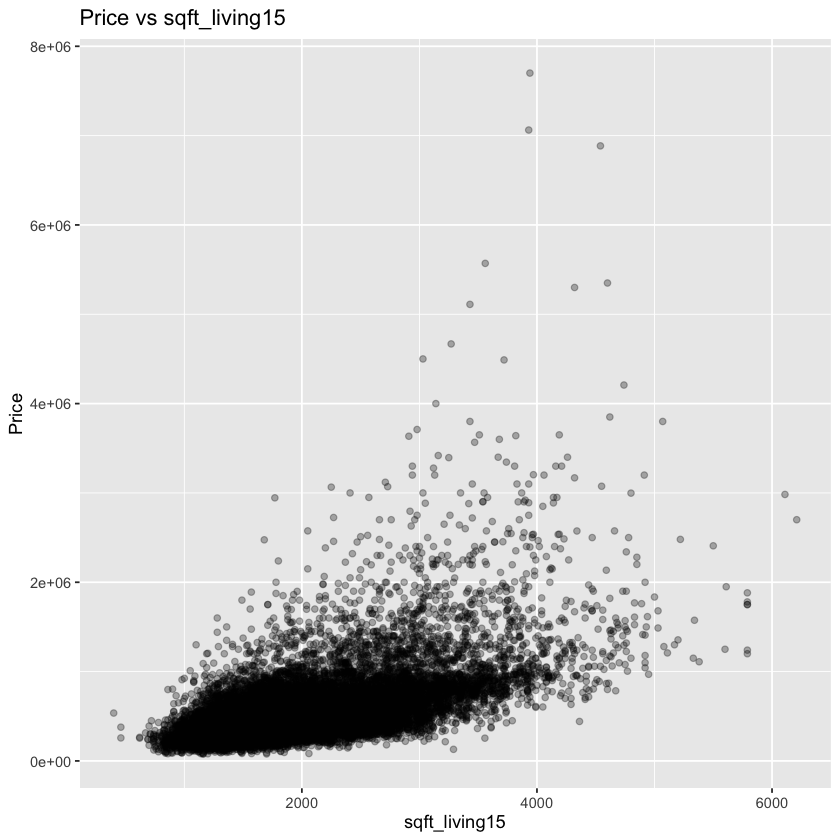

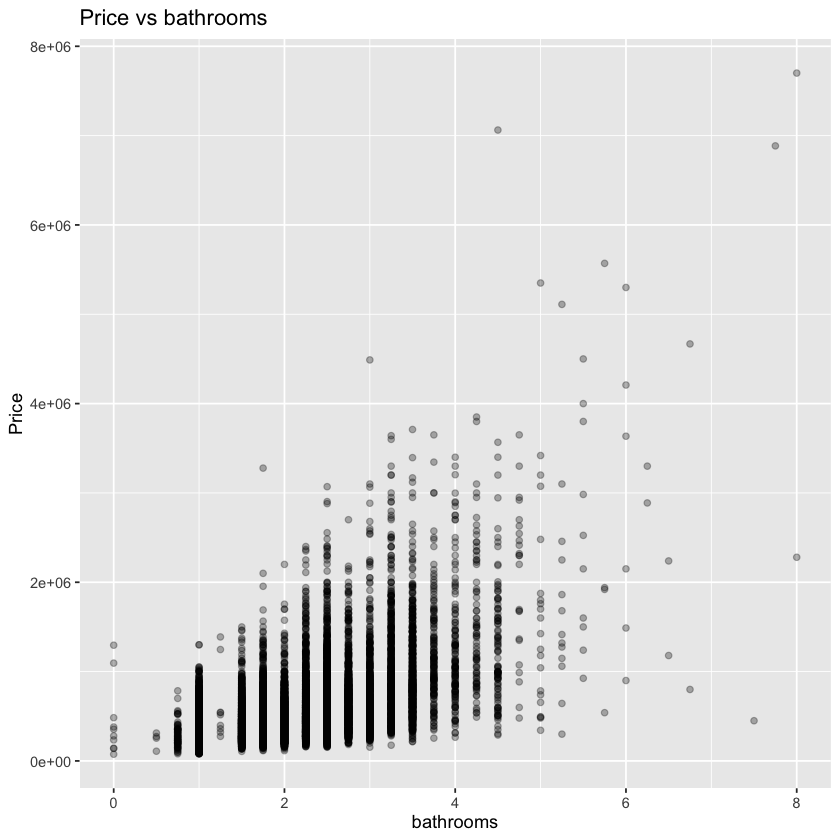

In [6]:
# EDA: Correlations + Top Scatterplots (Saved)

# Numeric-only subset using base R (safe)
num_df <- df_model[, sapply(df_model, is.numeric), drop = FALSE]

# Remove any zero-variance numeric columns (prevents cor() issues)
nzv <- sapply(num_df, function(x) sd(x) > 0)
num_df <- num_df[, nzv, drop = FALSE]

# Correlation matrix (use complete cases)
cor_mat <- cor(num_df, use = "complete.obs")

# Correlation with price
cor_with_price <- sort(cor_mat[, "price"], decreasing = TRUE)
cor_with_price

# Choose top 4 numeric predictors correlated with price (excluding price)
top_predictors <- names(cor_with_price)[names(cor_with_price) != "price"][1:4]
top_predictors

for (v in top_predictors) {
  p <- ggplot(df_model, aes(x = .data[[v]], y = price)) +
    geom_point(alpha = 0.3) +
    labs(title = paste("Price vs", v), x = v, y = "Price")
  ggsave(file.path(fig_dir, paste0("scatter_price_", v, ".png")), p, width = 7, height = 5, dpi = 200)
  print(p)
}


[1] "waterfront" "view"       "condition"  "grade"      "zipcode"

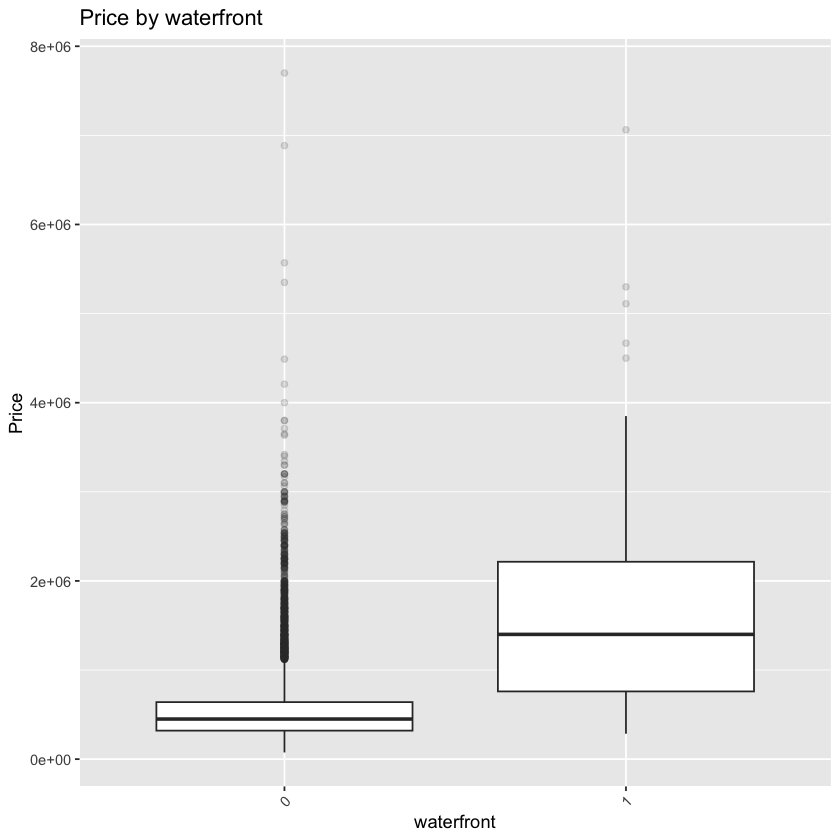

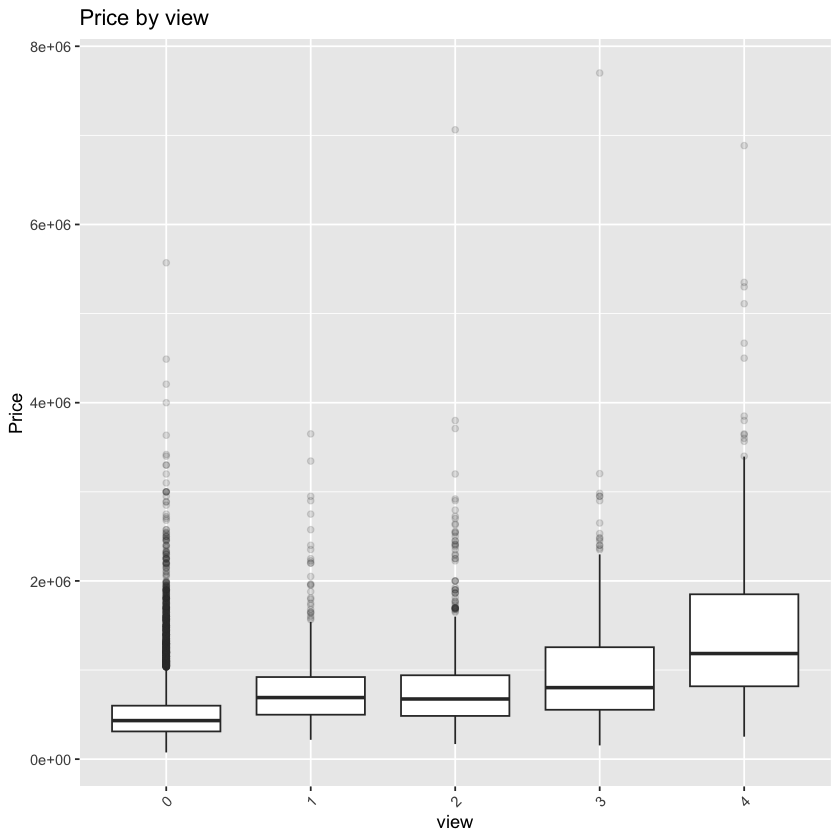

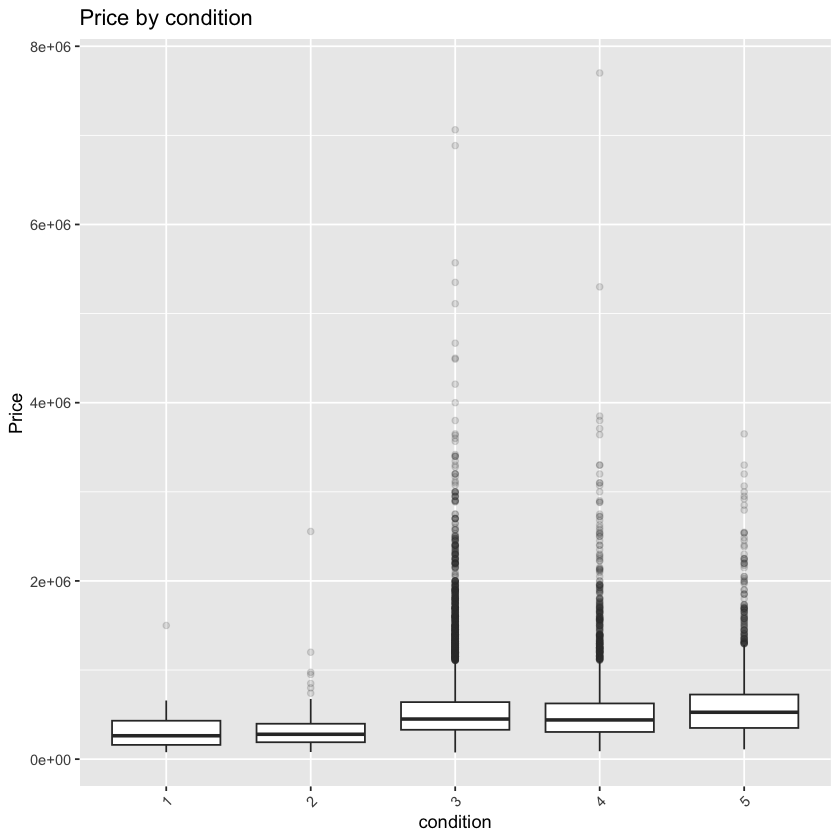

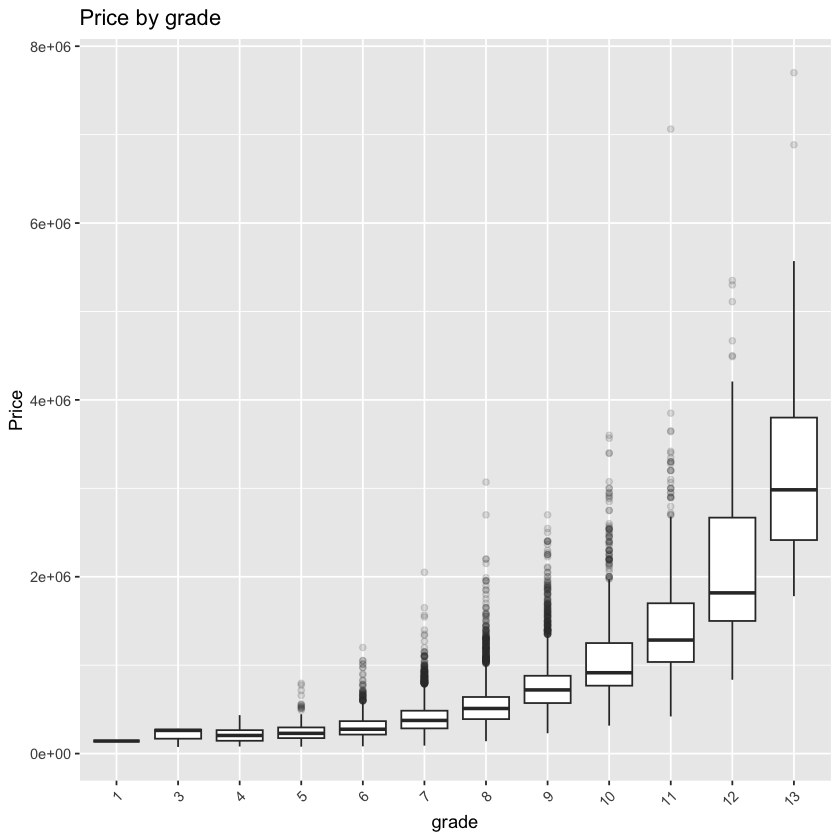

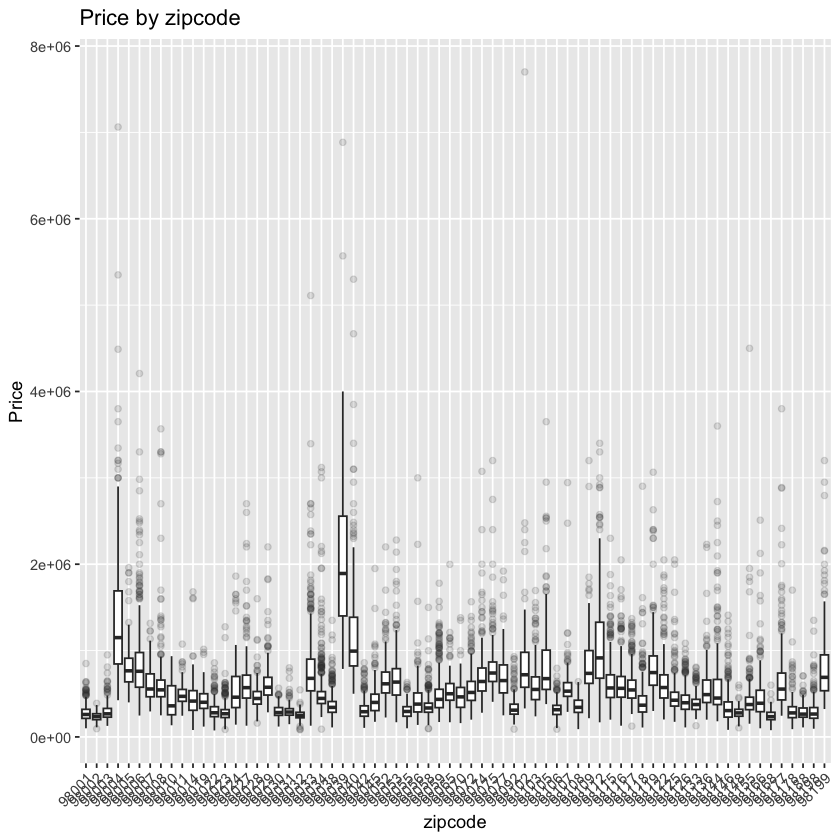

In [7]:
# EDA: Boxplots for Categorical Predictors (Saved)

cat_vars <- names(df_model)[sapply(df_model, is.factor)]
cat_vars

if (length(cat_vars) > 0) {
  for (v in cat_vars) {
    p <- ggplot(df_model, aes(x = .data[[v]], y = price)) +
      geom_boxplot(outlier.alpha = 0.15) +
      labs(title = paste("Price by", v), x = v, y = "Price") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1))
    ggsave(file.path(fig_dir, paste0("boxplot_price_", v, ".png")), p, width = 8, height = 5, dpi = 200)
    print(p)
  }
}


In [8]:
# Train/Test Split

set.seed(5703)
idx <- createDataPartition(df_model$price, p = 0.80, list = FALSE)
train <- df_model[idx, , drop = FALSE]
test  <- df_model[-idx, , drop = FALSE]

cat("Train rows:", nrow(train), "\nTest rows:", nrow(test), "\n")


Train rows: 17292 
Test rows: 4321 


In [9]:
# Baseline Multiple Linear Regression + Test Metrics

baseline_lm <- lm(price ~ ., data = train)
summary(baseline_lm)

pred_test <- predict(baseline_lm, newdata = test)
cat("Baseline LM Test RMSE:", RMSE(pred_test, test$price), "\n")
cat("Baseline LM Test R2:",   R2(pred_test, test$price), "\n")



Call:
lm(formula = price ~ ., data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1184886   -60664     1809    56964  3560686 

Coefficients: (1 not defined because of singularities)
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -3.270e+07  6.458e+06  -5.064 4.15e-07 ***
bedrooms      -1.157e+04  1.629e+03  -7.100 1.29e-12 ***
bathrooms      2.426e+04  2.786e+03   8.709  < 2e-16 ***
sqft_living    1.157e+02  3.731e+00  31.006  < 2e-16 ***
sqft_lot       2.675e-01  4.101e-02   6.523 7.08e-11 ***
floors        -2.756e+04  3.371e+03  -8.176 3.15e-16 ***
waterfront1    5.995e+05  1.756e+04  34.134  < 2e-16 ***
view1          8.259e+04  9.609e+03   8.595  < 2e-16 ***
view2          7.032e+04  5.890e+03  11.940  < 2e-16 ***
view3          1.400e+05  8.034e+03  17.425  < 2e-16 ***
view4          2.959e+05  1.289e+04  22.953  < 2e-16 ***
condition2     7.566e+04  3.505e+04   2.159 0.030901 *  
condition3     8.967e+04  3.280e+04   2.734 0.006272 *

Baseline LM Test RMSE: 137894.8 
Baseline LM Test R2: 0.8296817 


In [10]:
# Variable Selection: AIC Stepwise + Test Metrics

aic_lm <- step(baseline_lm, direction = "both", trace = 0)
summary(aic_lm)

pred_test_aic <- predict(aic_lm, newdata = test)
cat("AIC Model Test RMSE:", RMSE(pred_test_aic, test$price), "\n")
cat("AIC Model Test R2:",   R2(pred_test_aic, test$price), "\n")



Call:
lm(formula = price ~ bedrooms + bathrooms + sqft_living + sqft_lot + 
    floors + waterfront + view + condition + grade + sqft_above + 
    yr_built + yr_renovated + zipcode + lat + long + sqft_living15 + 
    sqft_lot15, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1184886   -60664     1809    56964  3560686 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -3.270e+07  6.458e+06  -5.064 4.15e-07 ***
bedrooms      -1.157e+04  1.629e+03  -7.100 1.29e-12 ***
bathrooms      2.426e+04  2.786e+03   8.709  < 2e-16 ***
sqft_living    1.157e+02  3.731e+00  31.006  < 2e-16 ***
sqft_lot       2.675e-01  4.101e-02   6.523 7.08e-11 ***
floors        -2.756e+04  3.371e+03  -8.176 3.15e-16 ***
waterfront1    5.995e+05  1.756e+04  34.134  < 2e-16 ***
view1          8.259e+04  9.609e+03   8.595  < 2e-16 ***
view2          7.032e+04  5.890e+03  11.940  < 2e-16 ***
view3          1.400e+05  8.034e+03  17.425  < 2e-16 ***
view4     

AIC Model Test RMSE: 137894.8 
AIC Model Test R2: 0.8296817 


In [11]:
# Variable Selection: BIC Stepwise + Test Metrics

bic_lm <- step(baseline_lm, direction = "both", k = log(nrow(train)), trace = 0)
summary(bic_lm)

pred_test_bic <- predict(bic_lm, newdata = test)
cat("BIC Model Test RMSE:", RMSE(pred_test_bic, test$price), "\n")
cat("BIC Model Test R2:",   R2(pred_test_bic, test$price), "\n")



Call:
lm(formula = price ~ bedrooms + bathrooms + sqft_living + sqft_lot + 
    floors + waterfront + view + condition + grade + sqft_above + 
    yr_built + yr_renovated + zipcode + long + sqft_living15, 
    data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1192369   -60805     1773    56802  3568571 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -2.563e+07  5.827e+06  -4.400 1.09e-05 ***
bedrooms      -1.150e+04  1.629e+03  -7.060 1.73e-12 ***
bathrooms      2.432e+04  2.786e+03   8.731  < 2e-16 ***
sqft_living    1.155e+02  3.730e+00  30.962  < 2e-16 ***
sqft_lot       2.129e-01  3.046e-02   6.990 2.85e-12 ***
floors        -2.766e+04  3.370e+03  -8.208 2.41e-16 ***
waterfront1    5.989e+05  1.756e+04  34.098  < 2e-16 ***
view1          8.292e+04  9.611e+03   8.628  < 2e-16 ***
view2          7.020e+04  5.891e+03  11.915  < 2e-16 ***
view3          1.399e+05  8.033e+03  17.419  < 2e-16 ***
view4          2.958e+05  1.2

BIC Model Test RMSE: 138025.4 
BIC Model Test R2: 0.8293627 


In [12]:
# Mallows’ Cp (Numeric-only) + Test Metrics (safe)

train_num <- train[, sapply(train, is.numeric), drop = FALSE]
test_num  <- test[,  sapply(test,  is.numeric), drop = FALSE]

stopifnot("price" %in% names(train_num))

# exhaustive subset search up to 20 predictors max (or all if fewer)
nv <- min(20, ncol(train_num) - 1)

cp_fit <- regsubsets(price ~ ., data = train_num, nvmax = nv, method = "exhaustive")
cp_sum <- summary(cp_fit)

cp_table <- data.frame(
  p = 1:length(cp_sum$cp),
  cp = cp_sum$cp,
  adjr2 = cp_sum$adjr2,
  bic = cp_sum$bic
)
cp_table <- cp_table[order(cp_table$cp), ]
head(cp_table, 10)

best_p <- cp_table$p[1]
cat("Best Cp model size:", best_p, "\n")

cp_coef <- coef(cp_fit, best_p)
cp_vars <- names(cp_coef)[-1]
cp_vars

cp_formula <- as.formula(paste("price ~", paste(cp_vars, collapse = " + ")))
cp_lm <- lm(cp_formula, data = train_num)
summary(cp_lm)

pred_test_cp <- predict(cp_lm, newdata = test_num)
cat("Cp Model Test RMSE:", RMSE(pred_test_cp, test_num$price), "\n")
cat("Cp Model Test R2:",   R2(pred_test_cp, test_num$price), "\n")


Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“1  linear dependencies found”


Reordering variables and trying again:


,p,cp,adjr2,bic
,<int>,<dbl>,<dbl>,<dbl>
12,12,12.00000,0.6258774,-16886.15
11,11,23.69155,0.6256026,-16882.22
10,10,30.23919,0.6254392,-16883.43
9,9,46.46980,0.6250662,-16874.97
8,8,103.93544,0.6238005,-16825.46
7,7,196.04781,0.6217851,-16741.82
6,6,504.60418,0.6150848,-16446.92
5,5,872.07022,0.6071102,-16101.09
4,4,1199.46399,0.6000038,-15799.87


Best Cp model size: 12 


[1] "bedrooms"      "bathrooms"     "sqft_living"   "sqft_lot"     
 [5] "floors"        "sqft_above"    "yr_renovated"  "lat"          
 [9] "long"          "sqft_living15" "sqft_lot15"    "sqft_basement"


Call:
lm(formula = cp_formula, data = train_num)

Residuals:
     Min       1Q   Median       3Q      Max 
-1389325  -120424   -15311    89866  4176886 

Coefficients: (1 not defined because of singularities)
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -7.804e+07  1.797e+06 -43.425  < 2e-16 ***
bedrooms      -4.894e+04  2.375e+03 -20.607  < 2e-16 ***
bathrooms      1.936e+04  3.920e+03   4.938 7.95e-07 ***
sqft_living    2.458e+02  5.396e+00  45.563  < 2e-16 ***
sqft_lot       2.951e-01  6.276e-02   4.703 2.59e-06 ***
floors        -1.415e+04  4.452e+03  -3.179  0.00148 ** 
sqft_above     2.511e+01  5.480e+00   4.582 4.65e-06 ***
yr_renovated   7.126e+01  4.532e+00  15.724  < 2e-16 ***
lat            6.470e+05  1.317e+04  49.127  < 2e-16 ***
long          -3.865e+05  1.436e+04 -26.918  < 2e-16 ***
sqft_living15  8.283e+01  4.189e+00  19.772  < 2e-16 ***
sqft_lot15    -4.583e-01  9.644e-02  -4.753 2.02e-06 ***
sqft_basement         NA         NA      NA      

Cp Model Test RMSE: 211399.8 
Cp Model Test R2: 0.5984359 


In [13]:
# 10-Fold Cross-Validation (caret)

ctrl <- trainControl(method = "cv", number = 10)

set.seed(5703)
cv_lm <- caret::train(
  price ~ .,
  data = train,
  method = "lm",
  trControl = ctrl,
  metric = "RMSE"
)

cv_lm
cat("10-fold CV RMSE (train):", cv_lm$results$RMSE, "\n")


Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


Linear Regression 

17292 samples
   18 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 15563, 15564, 15563, 15562, 15562, 15563, ... 
Resampling results:

  RMSE      Rsquared   MAE    
  154357.5  0.8316544  90326.5

Tuning parameter 'intercept' was held constant at a value of TRUE

10-fold CV RMSE (train): 154357.5 


In [14]:
# Multicollinearity (VIF)

# --- Fix: compute VIF after removing aliased columns ---

# Build design matrix from baseline model (includes dummies)
mm <- model.matrix(baseline_lm)

# Remove intercept
mm <- mm[, colnames(mm) != "(Intercept)", drop = FALSE]

# Keep only independent columns (remove exact linear dependencies)
qr_mm <- qr(mm)
independent_cols <- qr_mm$pivot[seq_len(qr_mm$rank)]
mm_ind <- mm[, independent_cols, drop = FALSE]

# Response vector
y <- model.response(model.frame(baseline_lm))

# IMPORTANT: turn matrix into a data frame so each column is its own term
X <- as.data.frame(mm_ind)

# Fit lm with separate predictors
lm_no_alias <- lm(y ~ ., data = X)

# Now VIF works (need at least 2 predictors)
if (ncol(X) < 2) {
  cat("Not enough independent predictors for VIF (ncol =", ncol(X), ").\n")
} else {
  vif_vals <- car::vif(lm_no_alias)
  vif_vals
}



bedrooms     bathrooms   sqft_living      sqft_lot        floors 
     1.747282      3.470683      8.973082      2.246993      2.487291 
  waterfront1         view1         view2         view3         view4 
     1.685045      1.055655      1.107433      1.122149      1.732189 
   condition2    condition3    condition4    condition5        grade3 
     7.392802    183.409375    156.298232     58.562506      4.198731 
       grade4        grade5        grade6        grade7        grade8 
    24.272056    203.236299   1537.073060   4467.282428   3712.370424 
       grade9       grade10       grade11       grade12       grade13 
  1984.169476    928.527341    334.261229     81.964816     14.980334 
   sqft_above      yr_built  yr_renovated  zipcode98002  zipcode98003 
     7.855412      3.157925      1.188733      1.589291      1.814269 
 zipcode98004  zipcode98005  zipcode98006  zipcode98007  zipcode98008 
     6.615025      4.149204      8.212399      3.759073      6.633064 
 zipcode98010  zipcode98011  zipcode98014  zipcode98019  zipcode98022 
     1.886075      7.835664      6.149655      8.906140      3.367008 
 zipcode98023  zipcode98024  zipcode98027  zipcode98028  zipcode98029 
     2.716125      3.103500      6.945556     10.398665      7.100012 
 zipcode98030  zipcode98031  zipcode98032  zipcode98033  zipcode98034 
     2.015459      2.313315      1.424985     11.652539     17.261585 
 zipcode98038  zipcode98039  zipcode98040  zipcode98042  zipcode98045 
     5.691406      2.063173      4.845414      3.847766      7.529062 
 zipcode98052  zipcode98053  zipcode98055  zipcode98056  zipcode98058 
    16.054097     12.890716      2.754359      4.875896      4.200417 
 zipcode98059  zipcode98065  zipcode98070  zipcode98072  zipcode98074 
     5.509693      8.526352      1.947858     10.912148     11.551004 
 zipcode98075  zipcode98077  zipcode98092  zipcode98102  zipcode98103 
     8.705879      8.249633      2.316927      3.070595     15.286830 
 zipcode98105  zipcode98106  zipcode98107  zipcode98108  zipcode98109 
     6.233989      4.786276      7.064332      3.242376      3.212470 
 zipcode98112  zipcode98115  zipcode98116  zipcode98117  zipcode98118 
     5.921736     15.055962      5.826028     14.190174      6.868648 
 zipcode98119  zipcode98122  zipcode98125  zipcode98126  zipcode98133 
     4.882643      6.017173     12.681521      5.201414     16.036598 
 zipcode98136  zipcode98144  zipcode98146  zipcode98148  zipcode98155 
     3.921261      6.198864      3.461563      1.335181     16.030276 
 zipcode98166  zipcode98168  zipcode98177  zipcode98178  zipcode98188 
     2.670075      3.139904      8.700155      3.266654      1.867136 
 zipcode98198  zipcode98199           lat          long sqft_living15 
     2.122104      7.476764     64.839114     34.016036      3.370202 
   sqft_lot15 
     2.411766

Warning message:
“not plotting observations with leverage one:
  15568”


agg_record_254504131 
                   2

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


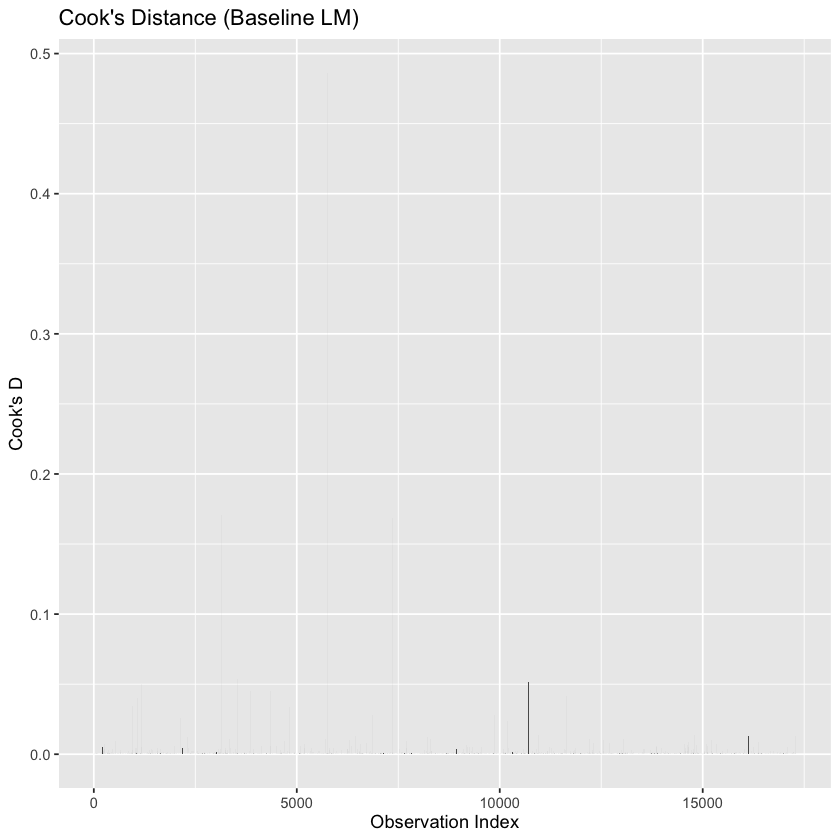

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


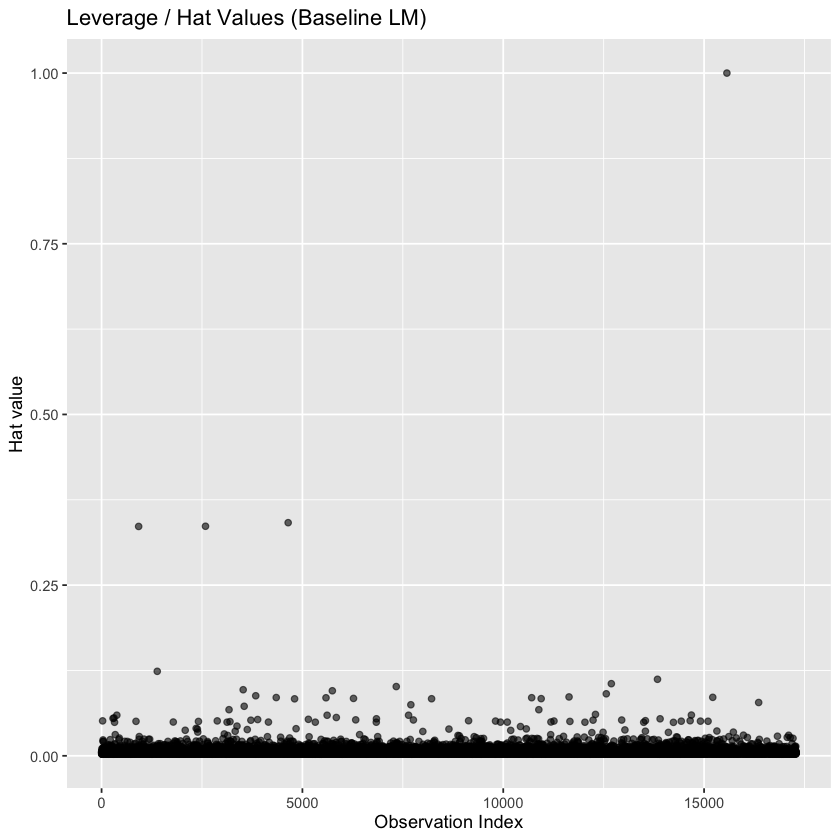

Potentially influential points flagged: 1461 


37  50  51  59  62  66  67  71 101 116 147 199 231 234 237 247 265 270 283 301 
 26  37  38  42  44  46  47  51  77  88 115 159 186 189 192 199 214 217 229 245

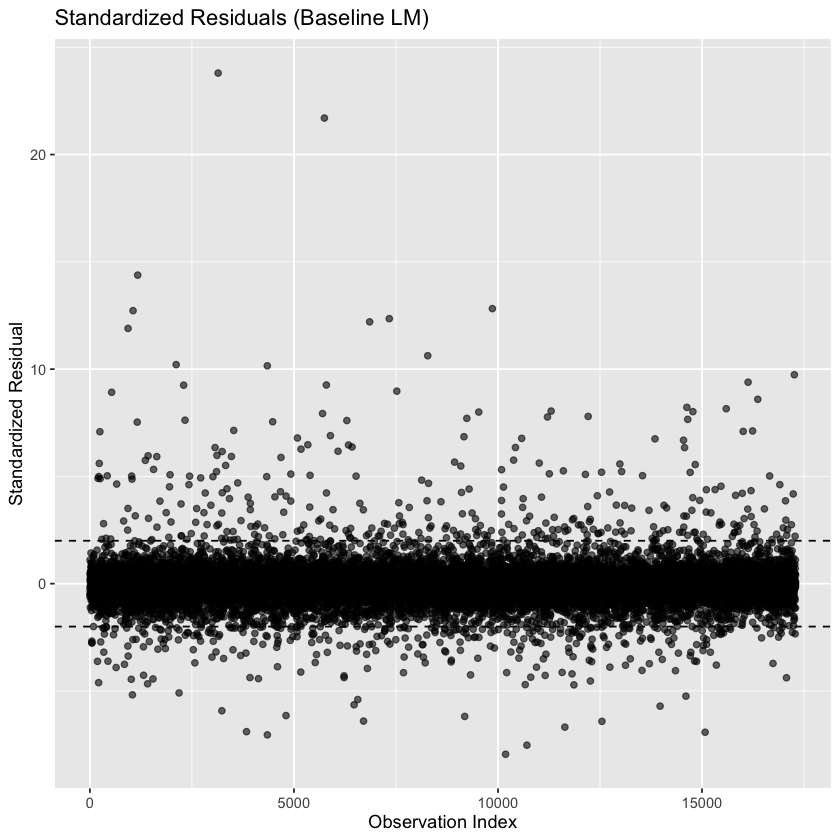

In [15]:
# Diagnostics + Influence (Saved)

# Standard diagnostic plots
png(file.path(fig_dir, "baseline_diagnostic_plots.png"), width = 1100, height = 900)
par(mfrow = c(2,2))
plot(baseline_lm)
dev.off()

# Cook's Distance
cooksd <- cooks.distance(baseline_lm)
p_cook <- ggplot(data.frame(i = seq_along(cooksd), cooksd = cooksd), aes(i, cooksd)) +
  geom_col() +
  labs(title = "Cook's Distance (Baseline LM)", x = "Observation Index", y = "Cook's D")
ggsave(file.path(fig_dir, "cooks_distance.png"), p_cook, width = 8, height = 4.5, dpi = 200)
p_cook

# Leverage / Hat values
hat <- hatvalues(baseline_lm)
p_hat <- ggplot(data.frame(i = seq_along(hat), hat = hat), aes(i, hat)) +
  geom_point(alpha = 0.6) +
  labs(title = "Leverage / Hat Values (Baseline LM)", x = "Observation Index", y = "Hat value")
ggsave(file.path(fig_dir, "hat_values.png"), p_hat, width = 8, height = 4.5, dpi = 200)
p_hat

# Standardized residuals
std_res <- rstandard(baseline_lm)
p_stdres <- ggplot(data.frame(i = seq_along(std_res), std_res = std_res), aes(i, std_res)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = c(-2, 2), linetype = 2) +
  labs(title = "Standardized Residuals (Baseline LM)", x = "Observation Index", y = "Standardized Residual")
ggsave(file.path(fig_dir, "standardized_residuals.png"), p_stdres, width = 8, height = 4.5, dpi = 200)
p_stdres

# Flag potentially influential points (simple thresholds)
n <- nrow(train)
p <- length(coef(baseline_lm))
cook_thresh <- 4 / n
lev_thresh  <- 2 * p / n

infl_idx <- which(cooksd > cook_thresh | hat > lev_thresh | abs(std_res) > 3)
cat("Potentially influential points flagged:", length(infl_idx), "\n")
head(infl_idx, 20)


In [16]:
# Transformation: log(price) Model + Diagnostics (Saved)

train_log <- train
test_log  <- test

train_log$log_price <- log(train_log$price)
test_log$log_price  <- log(test_log$price)

# Exclude original price from RHS
lm_log <- lm(log_price ~ . - price, data = train_log)
summary(lm_log)

pred_log <- predict(lm_log, newdata = test_log)
cat("Log-Price Model Test RMSE (log-scale):", RMSE(pred_log, test_log$log_price), "\n")
cat("Log-Price Model Test R2:",             R2(pred_log, test_log$log_price), "\n")

png(file.path(fig_dir, "logprice_diagnostic_plots.png"), width = 1100, height = 900)
par(mfrow = c(2,2))
plot(lm_log)
dev.off()



Call:
lm(formula = log_price ~ . - price, data = train_log)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.64783 -0.09698  0.00590  0.10415  1.08156 

Coefficients: (1 not defined because of singularities)
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -5.101e+01  7.764e+00  -6.569 5.20e-11 ***
bedrooms      -7.820e-04  1.959e-03  -0.399 0.689772    
bathrooms      3.905e-02  3.349e-03  11.659  < 2e-16 ***
sqft_living    1.272e-04  4.486e-06  28.348  < 2e-16 ***
sqft_lot       7.011e-07  4.931e-08  14.218  < 2e-16 ***
floors        -3.504e-02  4.053e-03  -8.645  < 2e-16 ***
waterfront1    4.425e-01  2.112e-02  20.957  < 2e-16 ***
view1          1.176e-01  1.155e-02  10.176  < 2e-16 ***
view2          1.064e-01  7.082e-03  15.023  < 2e-16 ***
view3          1.552e-01  9.659e-03  16.066  < 2e-16 ***
view4          2.748e-01  1.550e-02  17.732  < 2e-16 ***
condition2     1.124e-01  4.214e-02   2.667 0.007661 ** 
condition3     2.544e-01  3.944e-02   

Log-Price Model Test RMSE (log-scale): 0.185193 
Log-Price Model Test R2: 0.8712571 


Warning message:
“not plotting observations with leverage one:
  15568”


agg_record_800226704 
                   2

In [17]:
# Final Model Comparison Table (Saved)

results <- data.frame(
  model = c("Baseline LM", "AIC Stepwise", "BIC Stepwise", "Cp (numeric-only)", "Log-Price LM (log scale)"),
  test_RMSE = c(
    RMSE(predict(baseline_lm, newdata = test), test$price),
    RMSE(predict(aic_lm,     newdata = test), test$price),
    RMSE(predict(bic_lm,     newdata = test), test$price),
    RMSE(predict(cp_lm,      newdata = test_num), test_num$price),
    RMSE(predict(lm_log,     newdata = test_log), test_log$log_price)
  ),
  test_R2 = c(
    R2(predict(baseline_lm, newdata = test), test$price),
    R2(predict(aic_lm,     newdata = test), test$price),
    R2(predict(bic_lm,     newdata = test), test$price),
    R2(predict(cp_lm,      newdata = test_num), test_num$price),
    R2(predict(lm_log,     newdata = test_log), test_log$log_price)
  )
)

results
write.csv(results, file.path(fig_dir, "model_results_table.csv"), row.names = FALSE)

cat("Saved everything to:", fig_dir, "\n")
list.files(fig_dir)


model,test_RMSE,test_R2
<chr>,<dbl>,<dbl>
Baseline LM,1.378948e+05,0.8296817
AIC Stepwise,1.378948e+05,0.8296817
BIC Stepwise,1.380254e+05,0.8293627
Cp (numeric-only),2.113998e+05,0.5984359
Log-Price LM (log scale),1.851930e-01,0.8712571


Saved everything to: figures_step1 


[1] "baseline_diagnostic_plots.png"   "boxplot_price_condition.png"    
 [3] "boxplot_price_grade.png"         "boxplot_price_view.png"         
 [5] "boxplot_price_waterfront.png"    "boxplot_price_zipcode.png"      
 [7] "cooks_distance.png"              "hat_values.png"                 
 [9] "logprice_diagnostic_plots.png"   "logprice_hist.png"              
[11] "model_results_table.csv"         "price_hist.png"                 
[13] "scatter_price_bathrooms.png"     "scatter_price_sqft_above.png"   
[15] "scatter_price_sqft_living.png"   "scatter_price_sqft_living15.png"
[17] "standardized_residuals.png"